In [ ]:
# Setup
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Check version and if GPU available
print(f"TensorFlow version: {tf.__version__}")
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.19.0
GPU Available: []


In [ ]:
# Create simple test image (32×32 with 3 color channels)
test_image = np.random.randn(1, 32, 32, 3).astype(np.float32)
test_image = (test_image - test_image.min()) / (test_image.max() - test_image.min()) # Normalize to 0-1 so image can display properly
print(f"Input shape: {test_image.shape}") # Shape format: (batch_size, height, width, channels)

# Create simple convolutional layer
conv_layer = layers.Conv2D(
filters=16,         # Learn 16 different patterns
kernel_size=(3, 3), # Each filter is 3×3
strides=(1, 1),     # Move 1 pixel at a time
padding='same',     # Keep output size same as input
activation='relu',  # ReLU non-linearity
name='conv_layer_1'
)

# Apply the layer
output = conv_layer(test_image)
print(f"Output shape: {output.shape}") # 16 feature maps instead of 3 color channels

Input shape: (1, 32, 32, 3)
Output shape: (1, 32, 32, 16)


In [ ]:
# 1x1 Convolution

# Start with 64 channels
x = layers.Conv2D(filters=64, kernel_size=3,
padding='same', activation='relu')(test_image)
print(f"After first conv: {x.shape}")

# Use 1×1 to reduce to 16 channels ("bottleneck")
x = layers.Conv2D(filters=16, kernel_size=1, activation='relu', name='bottleneck')(x)
print(f"After 1×1 bottleneck: {x.shape}") # 64 to 16 channels

# Expand back up
x = layers.Conv2D(filters=64, kernel_size=1, activation='relu', name='expand')(x)
print(f"After 1×1 expansion: {x.shape}") # 16 to 64 channels

After first conv: (1, 32, 32, 64)
After 1×1 bottleneck: (1, 32, 32, 16)
After 1×1 expansion: (1, 32, 32, 64)


In [ ]:
# Conv2D Transpose (Upsampling)

# Start with a small feature map (downsampled)
small_features = layers.Conv2D(32, 3, strides=2, # Strides=2 halves spatial dimensions
                               padding='same')(test_image)
print(f"After downsampling conv: {small_features.shape}") # Spatial dimensions halved, 32×32 to 16×16

# Use Conv2DTranspose to upsample back
upsampled = layers.Conv2DTranspose(
filters=16,
kernel_size=3,
strides=2,        # Doubles spatial dimensions
padding='same',
activation='relu'
)(small_features)

print(f"After upsampling (transpose conv): {upsampled.shape}") # Back to 32×32

After downsampling conv: (1, 16, 16, 32)
After upsampling (transpose conv): (1, 32, 32, 16)


In [13]:
# Building CNN (combine all 3)

def build_simple_autoencoder():
  """
  Simple convolutional autoencoder
  Encoder: Conv -> Conv -> 1×1 bottleneck
  Decoder: 1×1 expand -> ConvTranspose -> ConvTranspose
  """
  inputs = keras.Input(shape=(32, 32, 3))

  # Encoder
  x = layers.Conv2D(32, 3, strides=2, padding='same', activation='relu', name='enc_conv1')(inputs)
  x = layers.Conv2D(64, 3, strides=2, padding='same', activation='relu', name='enc_conv2')(x)

  # Bottleneck: compress to compact encoding
  encoded = layers.Conv2D(8, (1, 1), activation='relu', name='bottleneck')(x) # Compact representation: 8×8 spatial with only 8 channels

  # Decoder
  # Expand channels back
  x = layers.Conv2D(64, (1, 1), activation='relu', name='expand')(encoded)

  # Upsample spatial dimensions
  x = layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu', name='dec_conv1')(x)
  x = layers.Conv2DTranspose(16, 3, strides=2, padding='same', activation='relu', name='dec_conv2')(x)

  # Final layer to get back to RGB
  outputs = layers.Conv2D(3, 3, padding='same', activation='sigmoid', # Add sigmoid activation as image is normalised to 0-1
                          name='output')(x)

  model = keras.Model(inputs=inputs, outputs=outputs)
  return model

# Build the model
model = build_simple_autoencoder()

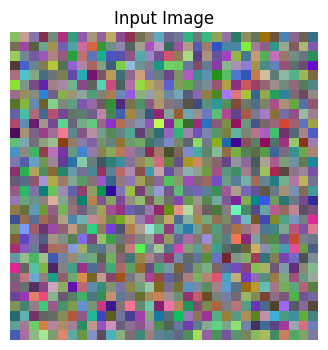

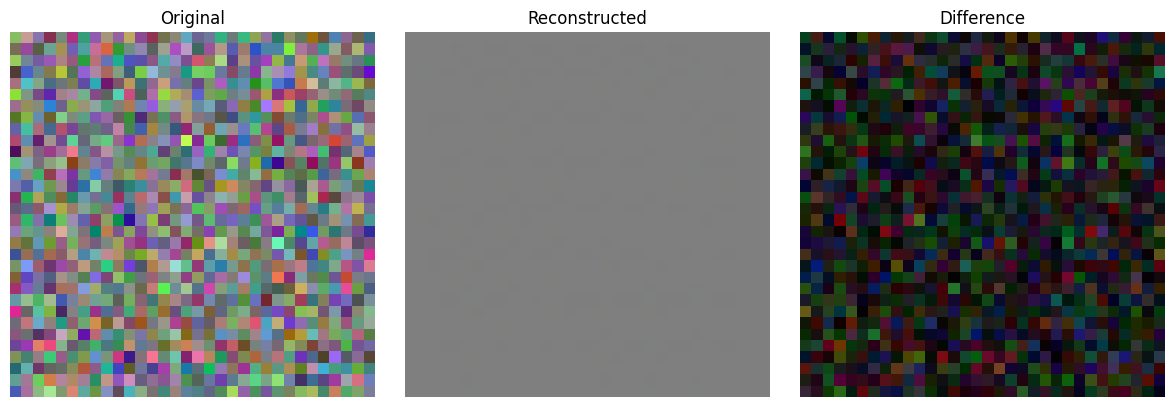

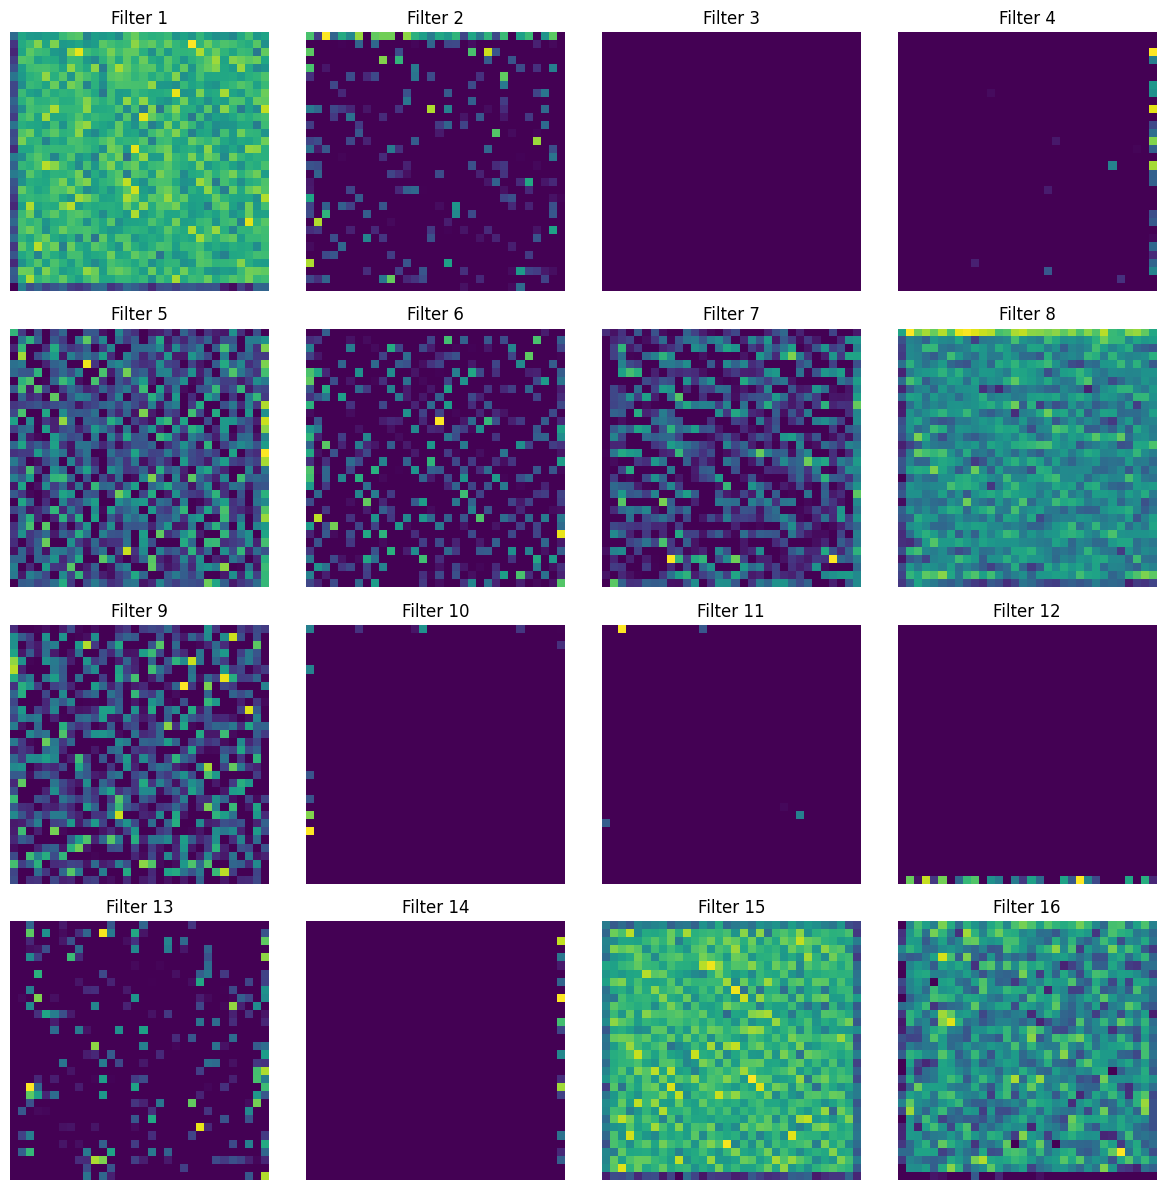

In [15]:
# Displaying images

# Display single image
plt.figure(figsize=(4, 4))
plt.imshow(test_image[0])  # Remove batch dimension
plt.title("Input Image")
plt.axis('off')
plt.show()

# Display multiple images side by side
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(test_image[0])
axes[0].set_title("Original")
axes[0].axis('off')

# After passing through model
output = model(test_image)
axes[1].imshow(np.clip(output[0].numpy(), 0, 1))  # Clip to [0, 1] range
axes[1].set_title("Reconstructed")
axes[1].axis('off')

# Difference map
axes[2].imshow(np.abs(test_image[0] - output[0].numpy()), cmap='hot')
axes[2].set_title("Difference")
axes[2].axis('off')
plt.tight_layout()
plt.show()

# Feature maps (showing what filters see)
conv_output = conv_layer(test_image)
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    if i < 16:  # For 16 filters
        ax.imshow(conv_output[0, :, :, i], cmap='viridis')
        ax.set_title(f'Filter {i+1}')
    ax.axis('off')
plt.tight_layout()
plt.show()

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0212 - mae: 0.1162
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0237 - mae: 0.1225
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0214 - mae: 0.1165
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0219 - mae: 0.1184
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0222 - mae: 0.1194
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0215 - mae: 0.1173
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0211 - mae: 0.1159
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0213 - mae: 0.1163
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0215 - mae: 0.1169
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0215 - mae: 0.1167
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0212 - mae: 0.1160
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0209 - mae: 0.1154
Epoch 13/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.020

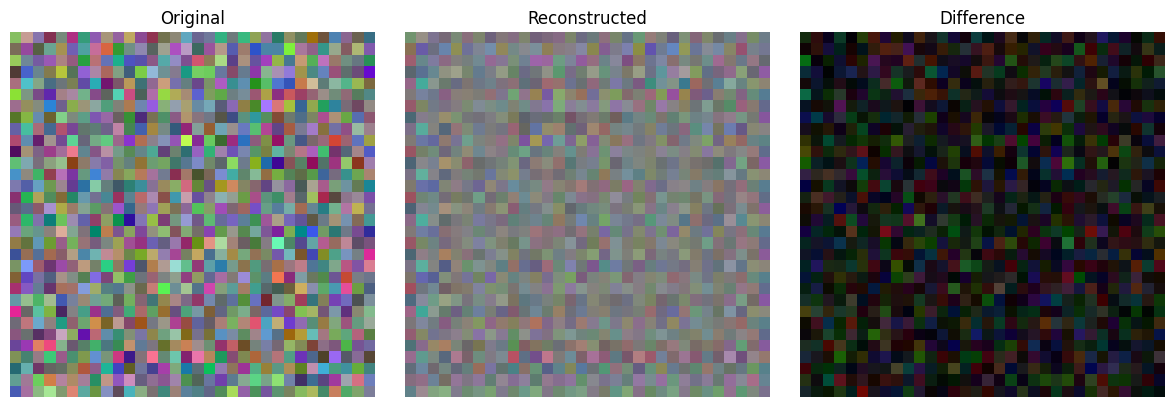

Final loss: 0.0183


In [18]:
# Training Model

# Compile model (set up optimizer and loss function)
model.compile(
    optimizer='adam',
    loss='mse',  # Mean Squared Error (good for reconstruction)
    metrics=['mae']  # Mean Absolute Error (helps track progress)
)

# Train model
# For autoencoder: input = output (it learns to reconstruct)
history = model.fit(
    test_image, test_image,  # x=input, y=target (same)
    epochs=50,               # Number of passes
    batch_size=32,           # Process 32 images at a time
    verbose=1                # Show progress
)

# Display trained images
output = model(test_image)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(test_image[0])
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(np.clip(output[0].numpy(), 0, 1))
axes[1].set_title("Reconstructed")
axes[1].axis('off')

diff = np.abs(test_image[0] - output[0].numpy())
axes[2].imshow(diff, cmap='hot')
axes[2].set_title("Difference")
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Final loss: {history.history['loss'][-1]:.4f}")

In [ ]:
# Training on real data (MSINT dataset)

# Load MNIST dataset
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Preprocess
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Pad to 32×32 and add channel dimension
x_train = np.pad(x_train, ((0,0), (2,2), (2,2)), mode='constant')
x_test = np.pad(x_test, ((0,0), (2,2), (2,2)), mode='constant')
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

# Repeat grayscale to 3 channels (to match model input shape)
x_train = np.repeat(x_train, 3, axis=-1)
x_test = np.repeat(x_test, 3, axis=-1)

print(f"Training data: {x_train.shape}")  # (60000, 32, 32, 3)
print(f"Test data: {x_test.shape}")       # (10000, 32, 32, 3)

# IMPORTANT: Rebuild the model with fresh weights
model = build_simple_autoencoder()

# Compile and train
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    x_train, x_train,
    batch_size=128,
    epochs=10,
    validation_data=(x_test, x_test),
    verbose=1
)

# Visualize results on test set
test_samples = x_test[:5]
reconstructed = model.predict(test_samples)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    axes[0, i].imshow(test_samples[i])
    axes[0, i].set_title('Original')
    axes[0, i].axis('off')

    axes[1, i].imshow(np.clip(reconstructed[i], 0, 1))
    axes[1, i].set_title('Reconstructed')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

Training data: (60000, 32, 32, 3)
Test data: (10000, 32, 32, 3)
Epoch 1/10
215/469 ━━━━━━━━━━━━━━━━━━━━ 47s 186ms/step - loss: 0.1360 - mae: 0.2394